<a href="https://colab.research.google.com/github/KurniaYufi/nlp-sentiment-analisis/blob/main/TF-IDF%20Homework/1C_TFIDF_Amerika_Iran.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Import Dependencies

In [1]:
import nltk
import math
import requests
import matplotlib.pyplot as plt
import pandas as pd
from bs4 import BeautifulSoup
from nltk.tokenize import sent_tokenize, word_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer

nltk.download('punkt')
nltk.download('punkt_tab')

!pip install Sastrawi -q
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 4.3 MB/s eta 0:00:00


# Scrape Article from URL

In [2]:
url = "https://www.bbc.com/indonesia/articles/cn5g1v6g7w2o"

headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
                  "AppleWebKit/537.36 (KHTML, like Gecko) "
                  "Chrome/120.0.0.0 Safari/537.36"
}

response = requests.get(url, headers=headers)
print("Status Code:", response.status_code)

Status Code: 200


In [3]:
soup = BeautifulSoup(response.text, 'html.parser')

# Ambil judul artikel
title = soup.find('h1')
title_text = title.get_text(strip=True) if title else "Judul tidak ditemukan"
print("Judul:", title_text)

# Ambil semua paragraf konten artikel
paragraphs = soup.find_all('p')
article_text = ' '.join([p.get_text(strip=True) for p in paragraphs if len(p.get_text(strip=True)) > 40])

print("\nPanjang teks artikel:", len(article_text), "karakter")
print("\nPreview teks:")
print(article_text[:500])

Judul: Pemimpin Iran, Ayatollah Ali Khamenei, wafat dalam serangan AS dan Israel

Panjang teks artikel: 13648 karakter

Preview teks:
Stasiun televisi pemerintah Iran mengumumkan 40 hari masa berkabung dan tujuh hari libur nasional menyusul wafatnya Pemimpin Tertinggi Iran, Ali Khamenei. Saluran beritaIRINNmenayangkan foto foto Khamenei dengan lantunan ayat suci Al-Qur'an sebagai latar, disertai pita hitam di pojok kiri atas layar. 'Penyiar membacakan pernyataan Dewan Keamanan Nasional Tertinggi (SNSC) yang secara resmi mengonfirmasi kematian Khamenei dan menuding Amerika Serikat serta Israel sebagai pihak yang bertanggung jaw


# Text Preprocessing

In [4]:
# Sentence tokenization
sent_token = sent_tokenize(article_text)
print(f"Jumlah kalimat: {len(sent_token)}")
print("\nDaftar kalimat:")
for i, sent in enumerate(sent_token):
    print(f"{i+1}. {sent}")

Jumlah kalimat: 105

Daftar kalimat:
1. Stasiun televisi pemerintah Iran mengumumkan 40 hari masa berkabung dan tujuh hari libur nasional menyusul wafatnya Pemimpin Tertinggi Iran, Ali Khamenei.
2. Saluran beritaIRINNmenayangkan foto foto Khamenei dengan lantunan ayat suci Al-Qur'an sebagai latar, disertai pita hitam di pojok kiri atas layar.
3. 'Penyiar membacakan pernyataan Dewan Keamanan Nasional Tertinggi (SNSC) yang secara resmi mengonfirmasi kematian Khamenei dan menuding Amerika Serikat serta Israel sebagai pihak yang bertanggung jawab.
4. Dalam pernyataan itu, Khamenei disebut wafat sebagai "martir" yang akan menjadi awal dari "kebangkitan dalam perjuangan melawan para penindas."
5. Dewan Keamanan Nasional Tertinggi Iran menyatakan bahwa Ayatollah Khamenei wafat pada Sabtu (28/02) dini hari di kantornya "saat sedang menjalankan tugas."
6. Media pemerintah Iran sebelumnya melaporkan bahwa putri Khamenei, menantunya, serta seorang cucunya turut tewas dalam serangan tersebut.
7. K

In [5]:
# Remove Indonesian stop words using Sastrawi
factory = StopWordRemoverFactory()
stopword_remover = factory.create_stop_word_remover()

cleaned_sentences = [stopword_remover.remove(sent) for sent in sent_token]

# Training TF-IDF Vectorizer on cleaned sentences
vectorizer = TfidfVectorizer()
features = vectorizer.fit_transform(cleaned_sentences)
feature_names = vectorizer.get_feature_names_out()

print("Shape of the Feature Matrix (sentences, unique words):", features.shape)
print("\nFeature Names (vocabulary after Indonesian stop word removal):")
print(feature_names)

Shape of the Feature Matrix (sentences, unique words): (105, 731)

Feature Names (vocabulary after Indonesian stop word removal):
['00' '02' '03' '09' '12' '13' '130' '153' '176' '2025' '2026' '26' '28'
 '30' '40' '47' '742' '787' '88' 'abad' 'abu' 'ada' 'adanya' 'adapun'
 'agency' 'ahli' 'ahwazi' 'akan' 'akhir' 'akibat' 'aktifkan' 'aktivis'
 'al' 'alasan' 'alasanoperasi' 'ali' 'alih' 'alihlah' 'ambil' 'ambisi'
 'amerika' 'an' 'anak' 'anda' 'anggota' 'anggotanya' 'angka' 'angkatan'
 'apabila' 'arab' 'arabmengatakan' 'arahan' 'armada' 'artikel' 'as' 'asap'
 'asasi' 'atas' 'awal' 'ayat' 'ayatollah' 'azeri' 'baca' 'bahrain'
 'balasan' 'balistik' 'baluchi' 'bandara' 'bangsa' 'bangunan' 'banyak'
 'baru' 'bbc' 'bebas' 'beberapa' 'belah' 'belenggu' 'benjamin' 'berada'
 'berafiliasi' 'beragam' 'berani' 'berbagai' 'berbatasan' 'berbunyi'
 'berdampak' 'beredar' 'berhasil' 'berita' 'beritafars' 'beritafarsdi'
 'beritairinnmenayangkan' 'beritakunamelaporkan' 'beritareutersmelaporkan'
 'beritatasni

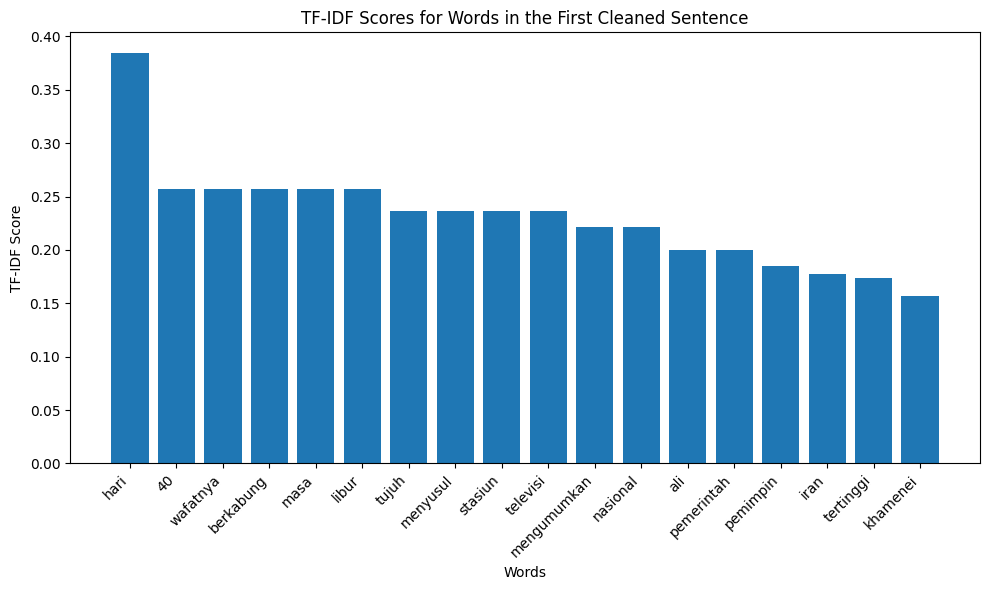


Top TF-IDF features in first sentence:
    Feature   TF-IDF
       hari 0.384596
         40 0.257100
   wafatnya 0.257100
  berkabung 0.257100
       masa 0.257100
      libur 0.257100
      tujuh 0.236126
   menyusul 0.236126
    stasiun 0.236126
   televisi 0.236126
mengumumkan 0.221245
   nasional 0.221245
        ali 0.200272
 pemerintah 0.200272
   pemimpin 0.185391
       iran 0.177135
  tertinggi 0.173848
   khamenei 0.156443


In [6]:
# Helper function to get TF-IDF scores for a specific sentence
def get_tfidf_for_sentence(features, sentence_index, feature_names):
    sentence_tfidf = features[sentence_index].toarray()[0]
    tfidf_df = pd.DataFrame({'Feature': feature_names, 'TF-IDF': sentence_tfidf})
    tfidf_df = tfidf_df[tfidf_df['TF-IDF'] > 0].sort_values('TF-IDF', ascending=False)
    return tfidf_df

# Visualize TF-IDF scores for the first cleaned sentence
first_sentence_tfidf_df = get_tfidf_for_sentence(features, 0, feature_names)

plt.figure(figsize=(10, 6))
plt.bar(first_sentence_tfidf_df['Feature'], first_sentence_tfidf_df['TF-IDF'])
plt.xlabel("Words")
plt.ylabel("TF-IDF Score")
plt.title("TF-IDF Scores for Words in the First Cleaned Sentence")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("\nTop TF-IDF features in first sentence:")
print(first_sentence_tfidf_df.to_string(index=False))

# Calculate TF-IDF Score per Sentence

In [7]:
# Variable initialization
sent_scores = []

# Calculate average TF-IDF score per sentence
for i in features:
    sent_score = i.sum()
    sent_length = len(i.data)
    avg_score = sent_score / sent_length if sent_length > 0 else 0
    sent_scores.append(avg_score)

# Threshold = average of all sentence scores
threshold = sum(sent_scores) / len(sent_scores) if sent_scores else 0
print("Threshold (Average of Sentence Scores):", threshold)

Threshold (Average of Sentence Scores): 0.27820467066119436


In [8]:
# Manual TF-IDF calculation
# Otomatis ambil kata yang paling sering muncul di artikel sebagai target word
def calculate_tf(term, document):
    words = word_tokenize(document.lower())
    return words.count(term) / len(words) if len(words) > 0 else 0

def calculate_idf(term, all_documents):
    num_docs_with_term = sum(1 for doc in all_documents if term.lower() in word_tokenize(doc.lower()))
    return math.log(len(all_documents) / num_docs_with_term) if num_docs_with_term > 0 else 0

# Pilih kata target: ambil kata dengan TF-IDF tertinggi di seluruh dokumen
overall_tfidf = features.sum(axis=0).A1
top_word_index = overall_tfidf.argmax()
target_word = feature_names[top_word_index]
print(f"Target word otomatis (TF-IDF tertinggi): '{target_word}'")
print("(Bisa diganti manual: target_word = 'kata_pilihan_anda')\n")

tfidf_scores = {}
for i, sent in enumerate(sent_token):
    cleaned_sent = stopword_remover.remove(sent)
    tf = calculate_tf(target_word, cleaned_sent)
    idf = calculate_idf(target_word, cleaned_sentences)
    tfidf_scores[f"Sentence {i+1}"] = tf * idf

print(f"TF-IDF Score for '{target_word}' in each sentence:")
for sent_num, score in tfidf_scores.items():
    print(f"{sent_num}: {score:.4f}")

overall_idf = calculate_idf(target_word, cleaned_sentences)
print(f"\nOverall IDF for '{target_word}': {overall_idf:.4f}")

# TF-IDF using sklearn for comparison
tfidf_col_index = list(feature_names).index(target_word) if target_word in feature_names else None
if tfidf_col_index is not None:
    print(f"\nTF-IDF Score for '{target_word}' using TfidfVectorizer:")
    for i, score in enumerate(features[:, tfidf_col_index].toarray().flatten()):
        print(f"Sentence {i+1}: {score:.4f}")

Target word otomatis (TF-IDF tertinggi): 'iran'
(Bisa diganti manual: target_word = 'kata_pilihan_anda')

TF-IDF Score for 'iran' in each sentence:
Sentence 1: 0.0674
Sentence 2: 0.0000
Sentence 3: 0.0000
Sentence 4: 0.0000
Sentence 5: 0.0323
Sentence 6: 0.0436
Sentence 7: 0.0000
Sentence 8: 0.0602
Sentence 9: 0.0436
Sentence 10: 0.0000
Sentence 11: 0.0000
Sentence 12: 0.0412
Sentence 13: 0.0000
Sentence 14: 0.0239
Sentence 15: 0.0000
Sentence 16: 0.0371
Sentence 17: 0.0618
Sentence 18: 0.0618
Sentence 19: 0.0353
Sentence 20: 0.0594
Sentence 21: 0.0000
Sentence 22: 0.0674
Sentence 23: 0.0390
Sentence 24: 0.0000
Sentence 25: 0.0000
Sentence 26: 0.0000
Sentence 27: 0.0464
Sentence 28: 0.0000
Sentence 29: 0.0000
Sentence 30: 0.0000
Sentence 31: 0.0000
Sentence 32: 0.0495
Sentence 33: 0.0000
Sentence 34: 0.0927
Sentence 35: 0.0000
Sentence 36: 0.0000
Sentence 37: 0.0000
Sentence 38: 0.0495
Sentence 39: 0.0000
Sentence 40: 0.0247
Sentence 41: 0.0000
Sentence 42: 0.0000
Sentence 43: 0.0824
S

# Get Summary Sentences

In [9]:
# Final summary initialization
final_summ = ""

# Include sentences with score >= threshold
for index, data in enumerate(sent_scores):
    if data >= threshold:
        final_summ = final_summ + " " + sent_token[index]
        print("-", sent_token[index])

- Sebelum itu, ia memimpin Pasukan Darat IRGC.
- Liputan mendalam BBC News Indonesia langsung di WhatsApp Anda.
- "Ini adalah kesempatan terbesar bagi rakyat Iran untuk mengambil kembali negaranya," tambahnya.
- BBC belum dapat memverifikasi laporan mengenai jumlah kematian di sekolah tersebut.
- Trump menyatakan AS telah melancarkan "operasi tempur besar-besaran" di Iran.
- Gambar "sebelum dan setelah" kini memperlihatkan sejauh mana kerusakan tersebut.
- Setelah serangan, bangunan-bangunan tampak menghitam dan puing-puing terlihat, dengan asap yang membubung tinggi.
- Lembaga ini terdiri atas 88 ulama yang secara formal dipilih rakyat setiap delapan tahun.
- Pada praktiknya hanya ulama yang dianggap paling loyal kepada Republik Islam yang diizinkan mencalonkan diri.
- Karena itu, mayoritas anggota majelis saat ini merupakan ulama garis keras seperti Ayatollah Khamenei.
- Konstitusi juga mengatur bahwa majelis tersebut harus memilih Pemimpin Tertinggi yang baru secepatnya.
- "Ketika k

# Summarization Result

In [10]:
print("=" * 60)
print("JUDUL:", title_text)
print("=" * 60)
print("RINGKASAN:")
print(final_summ.strip())

JUDUL: Pemimpin Iran, Ayatollah Ali Khamenei, wafat dalam serangan AS dan Israel
RINGKASAN:
Sebelum itu, ia memimpin Pasukan Darat IRGC. Liputan mendalam BBC News Indonesia langsung di WhatsApp Anda. "Ini adalah kesempatan terbesar bagi rakyat Iran untuk mengambil kembali negaranya," tambahnya. BBC belum dapat memverifikasi laporan mengenai jumlah kematian di sekolah tersebut. Trump menyatakan AS telah melancarkan "operasi tempur besar-besaran" di Iran. Gambar "sebelum dan setelah" kini memperlihatkan sejauh mana kerusakan tersebut. Setelah serangan, bangunan-bangunan tampak menghitam dan puing-puing terlihat, dengan asap yang membubung tinggi. Lembaga ini terdiri atas 88 ulama yang secara formal dipilih rakyat setiap delapan tahun. Pada praktiknya hanya ulama yang dianggap paling loyal kepada Republik Islam yang diizinkan mencalonkan diri. Karena itu, mayoritas anggota majelis saat ini merupakan ulama garis keras seperti Ayatollah Khamenei. Konstitusi juga mengatur bahwa majelis terse